# Analisis Awal, Pembersihan, dan Eksplorasi Dataset SSDC 2026

Notebook ini digunakan untuk:

1. membaca enam tabel pada folder **`Database SSDC 2026 UNZIP`**;
2. merapikan nama kolom, tipe data, teks, nomor telepon, dan tanggal;
3. memeriksa missing value, duplikasi, primary key, foreign key, serta konsistensi data;
4. mengeksplorasi pola pada **setiap tabel secara terpisah**;
5. menyimpan versi data yang sudah dibersihkan sebagai dasar analisis gabungan dan pembuatan dashboard.

## Batas analisis

Analisis ini masih bersifat **eksplorasi awal per tabel**. Notebook belum membangun model matching final dan belum menarik kesimpulan lintas tabel sebagai materi utama dashboard.

> **Catatan privasi:** dataset mengandung nama, NIM, e-mail, dan nomor telepon. Notebook tidak menampilkan daftar identitas lengkap dan hanya menggunakan data pribadi untuk pemeriksaan struktur.

## 1. Persiapan library dan tampilan

Library yang digunakan sengaja dibuat sederhana:

- `pandas` dan `numpy` untuk pengolahan data;
- `matplotlib` untuk visualisasi;
- `pathlib` untuk pengelolaan folder;
- `re` untuk pembersihan teks dan nomor telepon.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

Matplotlib is building the font cache; this may take a moment.


## 2. Menentukan lokasi folder data

Notebook akan mencari folder `Database SSDC 2026 UNZIP`. Apabila notebook diletakkan langsung di dalam folder tersebut, kode juga dapat membaca file dari folder aktif.

In [2]:
EXPECTED_FILES = {
    "company": "company.csv",
    "talent_request": "talent_request.csv",
    "student_all": "student_all.csv",
    "status_student": "status_student.csv",
    "tracking_company": "tracking_company.csv",
    "tracking_student": "tracking_student.csv",
}

candidate_dirs = [
    Path("Database SSDC 2026 UNZIP"),
    Path("."),
    Path("/mnt/data/Database SSDC 2026 UNZIP"),
    Path("/mnt/data"),
]

DATA_DIR = None
for candidate in candidate_dirs:
    if all((candidate / filename).exists() for filename in EXPECTED_FILES.values()):
        DATA_DIR = candidate.resolve()
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Folder data tidak ditemukan. Pastikan keenam CSV berada di folder "
        "'Database SSDC 2026 UNZIP' atau satu folder dengan notebook."
    )

print(f"Folder data: {DATA_DIR}")

Folder data: /mnt/data/Database SSDC 2026 UNZIP


## 3. Membaca seluruh tabel

Semua kolom dibaca terlebih dahulu sebagai teks. Pendekatan ini mencegah ID, NIM, dan nomor telepon kehilangan angka nol di bagian depan.

File `status_student.csv` menggunakan pemisah titik koma (`;`), sedangkan lima file lain menggunakan koma.

In [3]:
def read_table(path, separator=","):
    return pd.read_csv(
        path,
        sep=separator,
        dtype="string",
        encoding="utf-8-sig",
        low_memory=False,
    )

raw_tables = {
    "company": read_table(DATA_DIR / EXPECTED_FILES["company"]),
    "talent_request": read_table(DATA_DIR / EXPECTED_FILES["talent_request"]),
    "student_all": read_table(DATA_DIR / EXPECTED_FILES["student_all"]),
    "status_student": read_table(
        DATA_DIR / EXPECTED_FILES["status_student"],
        separator=";",
    ),
    "tracking_company": read_table(DATA_DIR / EXPECTED_FILES["tracking_company"]),
    "tracking_student": read_table(DATA_DIR / EXPECTED_FILES["tracking_student"]),
}

shape_overview = pd.DataFrame(
    [
        {
            "tabel": name,
            "jumlah_baris": len(df),
            "jumlah_kolom": df.shape[1],
        }
        for name, df in raw_tables.items()
    ]
)

display(shape_overview)

,tabel,jumlah_baris,jumlah_kolom
0,company,1500,9
1,talent_request,12000,19
2,student_all,25000,10
3,status_student,25000,15
4,tracking_company,12000,13
5,tracking_student,41600,11


### Pemeriksaan nama kolom

Bagian ini memastikan struktur file sesuai dengan dokumentasi ERD. Apabila ada kolom yang hilang atau berubah nama, perbedaannya akan segera terlihat.

In [4]:
for name, df in raw_tables.items():
    print(f"\n{name.upper()} ({df.shape[0]:,} baris × {df.shape[1]} kolom)")
    print(df.columns.tolist())


COMPANY (1,500 baris × 9 kolom)
['id_company', 'company_name', 'company_type', 'industry_sector', 'kota', 'skala_perusahaan', 'pic_name', 'pic_phone', 'created_at']

TALENT_REQUEST (12,000 baris × 19 kolom)
['id_talent_req', 'id_company', 'nama_perusahaan', 'alamat_kantor', 'industri_sektor', 'nama_pic', 'no_whatsapp', 'nama_posisi', 'jenis_penempatan', 'headcount', 'bidang_studi_dibutuhkan', 'minimum_semester', 'deskripsi_requirement', 'working_arrangement', 'working_arrangement_detail', 'durasi', 'renumerasi', 'request_date', 'sumber_baris_form']

STUDENT_ALL (25,000 baris × 10 kolom)
['NIM', 'nama', 'program_studi', 'semester', 'hp', 'email_pribadi', 'email_kampus', 'bidang_minat', 'jenis_penempatan_diminati', 'bulan_masuk']

STATUS_STUDENT (25,000 baris × 15 kolom)
['id_status', 'NIM', 'email', 'nama', 'semester', 'program_studi', 'no_whatsapp', 'CV', 'portofolio', 'IPK', 'status', 'domisili', 'ketersediaan', 'tools', 'sync_date']

TRACKING_COMPANY (12,000 baris × 13 kolom)
['id_t

## 4. Fungsi pembersihan

Fungsi berikut digunakan berulang agar proses pembersihan konsisten.

Pembersihan yang dilakukan:

- mengubah nama kolom menjadi `snake_case`;
- menghapus spasi berlebih;
- mengubah teks kosong menjadi missing value;
- menormalkan nomor telepon Indonesia;
- mengubah kolom numerik dan tanggal;
- memecah teks multi-value seperti daftar tools.

In [5]:
def to_snake_case(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def clean_base(df):
    result = df.copy()
    result.columns = [to_snake_case(col) for col in result.columns]

    for col in result.columns:
        if pd.api.types.is_string_dtype(result[col]):
            result[col] = (
                result[col]
                .astype("string")
                .str.strip()
                .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
            )
    return result


def normalize_phone(series):
    def clean_one(value):
        if pd.isna(value):
            return pd.NA

        digits = re.sub(r"\D", "", str(value))

        if digits.startswith("62"):
            digits = "0" + digits[2:]
        elif digits.startswith("8"):
            digits = "0" + digits

        return digits if digits else pd.NA

    return series.apply(clean_one).astype("string")


def to_numeric_safe(series):
    return pd.to_numeric(series, errors="coerce")


def parse_date(series, date_format):
    return pd.to_datetime(series, format=date_format, errors="coerce")


def split_multivalue(series, separator=","):
    return (
        series.dropna()
        .str.split(separator)
        .explode()
        .str.strip()
        .replace("", pd.NA)
        .dropna()
    )


def parse_indonesian_month(series):
    month_map = {
        "Januari": "01",
        "Februari": "02",
        "Maret": "03",
        "April": "04",
        "Mei": "05",
        "Juni": "06",
        "Juli": "07",
        "Agustus": "08",
        "September": "09",
        "Oktober": "10",
        "November": "11",
        "Desember": "12",
    }

    extracted = series.str.extract(r"(?P<bulan>[A-Za-z]+)\s+(?P<tahun>\d{4})")
    month_number = extracted["bulan"].map(month_map)

    return pd.to_datetime(
        extracted["tahun"] + "-" + month_number + "-01",
        errors="coerce",
    )


def extract_rupiah_amount(series):
    return pd.to_numeric(
        series.str.replace(r"\D", "", regex=True).replace("", pd.NA),
        errors="coerce",
    )


def plot_count_bar(series, title, xlabel="Jumlah", top_n=None):
    counts = series.value_counts(dropna=False)
    if top_n is not None:
        counts = counts.head(top_n)

    counts = counts.sort_values()

    plt.figure(figsize=(9, max(4, len(counts) * 0.38)))
    counts.plot(kind="barh")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("")
    plt.grid(axis="x", alpha=0.25)

    for index, value in enumerate(counts.values):
        plt.text(value, index, f" {value:,.0f}", va="center")

    plt.tight_layout()
    plt.show()


def plot_histogram(series, title, xlabel, bins=20):
    values = series.dropna()

    plt.figure(figsize=(9, 4.8))
    plt.hist(values, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frekuensi")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_time_series(series, title, xlabel="Periode", ylabel="Jumlah"):
    values = series.sort_index()

    plt.figure(figsize=(11, 4.8))
    plt.plot(values.index, values.values, marker="o", linewidth=1.5)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 5. Membersihkan masing-masing tabel

Pembersihan dilakukan per tabel agar grain atau unit observasi setiap tabel tetap terjaga.

In [6]:
# COMPANY
company = clean_base(raw_tables["company"])
company["pic_phone"] = normalize_phone(company["pic_phone"])
company["created_at"] = parse_date(company["created_at"], "%Y-%m-%d")
company["registration_year"] = company["created_at"].dt.year.astype("Int64")


# TALENT REQUEST
talent_request = clean_base(raw_tables["talent_request"])
talent_request["no_whatsapp"] = normalize_phone(talent_request["no_whatsapp"])

for col in ["headcount", "minimum_semester"]:
    talent_request[col] = to_numeric_safe(talent_request[col]).astype("Int64")

talent_request["request_date"] = parse_date(
    talent_request["request_date"],
    "%Y-%m-%d",
)
talent_request["request_month"] = (
    talent_request["request_date"].dt.to_period("M").dt.to_timestamp()
)
talent_request["duration_months"] = (
    talent_request["durasi"]
    .str.extract(r"(\d+)", expand=False)
    .pipe(to_numeric_safe)
    .astype("Int64")
)
talent_request["remuneration_amount"] = extract_rupiah_amount(
    talent_request["renumerasi"]
)
talent_request["remuneration_type"] = np.select(
    [
        talent_request["renumerasi"].str.contains(
            "Non-Paid",
            case=False,
            na=False,
        ),
        talent_request["renumerasi"].str.contains(
            "transport",
            case=False,
            na=False,
        ),
        talent_request["remuneration_amount"].notna(),
    ],
    [
        "Non-Paid",
        "Transport Only",
        "Paid",
    ],
    default="Other",
)
talent_request["required_study_count"] = (
    talent_request["bidang_studi_dibutuhkan"]
    .fillna("")
    .str.split(",")
    .str.len()
)


# STUDENT ALL
student_all = clean_base(raw_tables["student_all"])
student_all["nim"] = student_all["nim"].astype("string")
student_all["hp"] = normalize_phone(student_all["hp"])
student_all["semester"] = to_numeric_safe(student_all["semester"]).astype("Int64")
student_all["entry_date"] = parse_indonesian_month(student_all["bulan_masuk"])
student_all["entry_year"] = student_all["entry_date"].dt.year.astype("Int64")


# STATUS STUDENT
status_student = clean_base(raw_tables["status_student"])
status_student["nim"] = status_student["nim"].astype("string")
status_student["no_whatsapp"] = normalize_phone(
    status_student["no_whatsapp"]
)
status_student["semester"] = to_numeric_safe(
    status_student["semester"]
).astype("Int64")
status_student["ipk"] = to_numeric_safe(status_student["ipk"])
status_student["sync_date"] = parse_date(
    status_student["sync_date"],
    "%d/%m/%Y",
)
status_student["tools_count"] = (
    status_student["tools"]
    .fillna("")
    .str.split(",")
    .str.len()
)
status_student["basic_ready"] = (
    status_student["status"].eq("Active")
    & status_student["ketersediaan"].eq("Available")
    & status_student["cv"].eq("Ada")
)

status_reference_date = status_student["sync_date"].max()
status_student["days_since_sync"] = (
    status_reference_date - status_student["sync_date"]
).dt.days


# TRACKING COMPANY
tracking_company = clean_base(raw_tables["tracking_company"])

for col in ["jumlah_permintaan", "jumlah_dikirimkan"]:
    tracking_company[col] = to_numeric_safe(
        tracking_company[col]
    ).astype("Int64")

tracking_company["request_date"] = parse_date(
    tracking_company["request_date"],
    "%d/%m/%Y",
)
tracking_company["send_date"] = parse_date(
    tracking_company["send_date"],
    "%d/%m/%Y",
)
tracking_company["days_to_send"] = (
    tracking_company["send_date"] - tracking_company["request_date"]
).dt.days
tracking_company["candidate_gap"] = (
    tracking_company["jumlah_dikirimkan"]
    - tracking_company["jumlah_permintaan"]
)
tracking_company["coverage_ratio"] = (
    tracking_company["jumlah_dikirimkan"]
    / tracking_company["jumlah_permintaan"].replace(0, np.nan)
)
tracking_company["list_nim_count"] = (
    tracking_company["list_nim"]
    .fillna("")
    .apply(
        lambda value: len(
            [nim.strip() for nim in value.split(",") if nim.strip()]
        )
    )
)


# TRACKING STUDENT
tracking_student = clean_base(raw_tables["tracking_student"])
tracking_student["nim"] = tracking_student["nim"].astype("string")
tracking_student["internship_semester"] = to_numeric_safe(
    tracking_student["internship_semester"]
).astype("Int64")
tracking_student["last_update"] = parse_date(
    tracking_student["last_update"],
    "%Y-%m-%d",
)

tracking_student["outcome_group"] = "On Progress"

placement_mask = (
    tracking_student["rejection"].eq("Placement")
    | tracking_student["progress_student"].eq("Placement")
)
ghosting_mask = (
    tracking_student["rejection"].eq("Ghosting")
    | tracking_student["progress_student"].eq("Ghosting")
)
rejected_mask = (
    tracking_student["rejection"].str.startswith(
        "Rejection",
        na=False,
    )
    | tracking_student["progress_student"].eq("Rejected")
)
finish_unclear_mask = (
    tracking_student["progress_student"].eq("Finish")
    & tracking_student["rejection"].eq("On Progress")
)

tracking_student.loc[placement_mask, "outcome_group"] = "Placement"
tracking_student.loc[ghosting_mask, "outcome_group"] = "Ghosting"
tracking_student.loc[rejected_mask, "outcome_group"] = "Rejected"
tracking_student.loc[
    finish_unclear_mask,
    "outcome_group",
] = "Finish - Unclear"

tracking_reference_date = tracking_student["last_update"].max()
tracking_student["days_since_update"] = (
    tracking_reference_date - tracking_student["last_update"]
).dt.days


clean_tables = {
    "company": company,
    "talent_request": talent_request,
    "student_all": student_all,
    "status_student": status_student,
    "tracking_company": tracking_company,
    "tracking_student": tracking_student,
}

print("Pembersihan dasar selesai.")

Pembersihan dasar selesai.


## 6. Ringkasan kualitas data setelah pembersihan

Ringkasan berikut memperlihatkan:

- jumlah baris dan kolom;
- jumlah serta persentase missing value;
- jumlah baris duplikat;
- jumlah kolom tanggal yang gagal diparsing.

In [7]:
date_columns = {
    "company": ["created_at"],
    "talent_request": ["request_date"],
    "student_all": ["entry_date"],
    "status_student": ["sync_date"],
    "tracking_company": ["request_date", "send_date"],
    "tracking_student": ["last_update"],
}

quality_summary = []

for name, df in clean_tables.items():
    total_cells = df.shape[0] * df.shape[1]
    missing_cells = int(df.isna().sum().sum())
    date_parse_missing = int(
        df[date_columns[name]].isna().sum().sum()
    )

    quality_summary.append(
        {
            "tabel": name,
            "baris": len(df),
            "kolom_setelah_feature": df.shape[1],
            "missing_cells": missing_cells,
            "missing_percent": (
                missing_cells / total_cells * 100
                if total_cells
                else 0
            ),
            "duplicate_rows": int(df.duplicated().sum()),
            "missing_pada_kolom_tanggal": date_parse_missing,
        }
    )

quality_summary = pd.DataFrame(quality_summary)
display(quality_summary)

,tabel,baris,kolom_setelah_feature,missing_cells,missing_percent,duplicate_rows,missing_pada_kolom_tanggal
0,company,1500,10,0,0.00,0,0
1,talent_request,12000,24,3758,1.30,0,0
2,student_all,25000,12,0,0.00,0,0
3,status_student,25000,18,0,0.00,0,0
4,tracking_company,12000,17,1794,0.88,0,598
5,tracking_student,41600,13,0,0.00,0,0


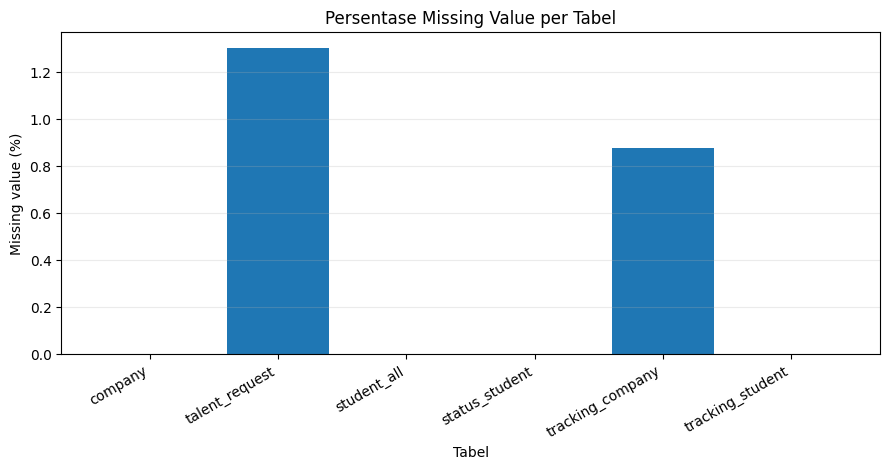

In [8]:
plt.figure(figsize=(9, 4.8))
plt.bar(
    quality_summary["tabel"],
    quality_summary["missing_percent"],
)
plt.title("Persentase Missing Value per Tabel")
plt.xlabel("Tabel")
plt.ylabel("Missing value (%)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Missing value per kolom

Missing value perlu dibaca bersama konteks proses bisnis. Sebagai contoh, `send_date` dan `list_nim` yang kosong pada request berstatus `Draft` dapat merupakan kondisi logis, bukan kesalahan input.

In [9]:
missing_by_column = []

for name, df in clean_tables.items():
    for column, count in df.isna().sum().items():
        if count > 0:
            missing_by_column.append(
                {
                    "tabel": name,
                    "kolom": column,
                    "jumlah_missing": int(count),
                    "persentase": count / len(df) * 100,
                }
            )

missing_by_column = pd.DataFrame(missing_by_column)

if missing_by_column.empty:
    print("Tidak ada missing value.")
else:
    display(
        missing_by_column.sort_values(
            ["jumlah_missing", "tabel"],
            ascending=[False, True],
        )
    )

,tabel,kolom,jumlah_missing,persentase
1,talent_request,remuneration_amount,2570,21.42
0,talent_request,duration_months,1188,9.90
2,tracking_company,send_date,598,4.98
3,tracking_company,list_nim,598,4.98
4,tracking_company,days_to_send,598,4.98


## 7. Pemeriksaan primary key dan relasi

Pemeriksaan ini belum menghasilkan insight bisnis gabungan. Tujuannya hanya memastikan struktur relasional sesuai ERD dan aman digunakan pada analisis lanjutan.

In [10]:
primary_keys = {
    "company": "id_company",
    "talent_request": "id_talent_req",
    "student_all": "nim",
    "status_student": "id_status",
    "tracking_company": "id_tracking_company",
    "tracking_student": "id_tracking_student",
}

pk_checks = []

for table_name, key in primary_keys.items():
    df = clean_tables[table_name]
    pk_checks.append(
        {
            "tabel": table_name,
            "primary_key": key,
            "missing_key": int(df[key].isna().sum()),
            "duplicate_key": int(df[key].duplicated().sum()),
            "unique_key": int(df[key].nunique(dropna=True)),
        }
    )

pk_checks = pd.DataFrame(pk_checks)
display(pk_checks)

,tabel,primary_key,missing_key,duplicate_key,unique_key
0,company,id_company,0,0,1500
1,talent_request,id_talent_req,0,0,12000
2,student_all,nim,0,0,25000
3,status_student,id_status,0,0,25000
4,tracking_company,id_tracking_company,0,0,12000
5,tracking_student,id_tracking_student,0,0,41600


In [11]:
foreign_key_checks = pd.DataFrame(
    [
        {
            "relasi": "talent_request.id_company → company.id_company",
            "record_tidak_cocok": int(
                (~talent_request["id_company"].isin(company["id_company"])).sum()
            ),
        },
        {
            "relasi": "tracking_company.id_company → company.id_company",
            "record_tidak_cocok": int(
                (~tracking_company["id_company"].isin(company["id_company"])).sum()
            ),
        },
        {
            "relasi": "tracking_company.id_talent_req → talent_request.id_talent_req",
            "record_tidak_cocok": int(
                (~tracking_company["id_talent_req"].isin(
                    talent_request["id_talent_req"]
                )).sum()
            ),
        },
        {
            "relasi": "status_student.nim → student_all.nim",
            "record_tidak_cocok": int(
                (~status_student["nim"].isin(student_all["nim"])).sum()
            ),
        },
        {
            "relasi": "tracking_student.nim → student_all.nim",
            "record_tidak_cocok": int(
                (~tracking_student["nim"].isin(student_all["nim"])).sum()
            ),
        },
        {
            "relasi": (
                "tracking_student.id_tracking_company → "
                "tracking_company.id_tracking_company"
            ),
            "record_tidak_cocok": int(
                (~tracking_student["id_tracking_company"].isin(
                    tracking_company["id_tracking_company"]
                )).sum()
            ),
        },
    ]
)

display(foreign_key_checks)

,relasi,record_tidak_cocok
0,talent_request.id_company → company.id_company,0
1,tracking_company.id_company → company.id_company,0
2,tracking_company.id_talent_req → talent_reques...,0
3,status_student.nim → student_all.nim,0
4,tracking_student.nim → student_all.nim,0
5,tracking_student.id_tracking_company → trackin...,0


### Validasi kolom terdenormalisasi

Beberapa nama perusahaan, posisi, program studi, dan tanggal disalin ke tabel lain agar mudah dibaca. Nilai tersebut perlu dibandingkan dengan tabel sumber agar tidak menciptakan konflik saat proses join.

In [12]:
company_to_request = talent_request.merge(
    company[["id_company", "company_name", "industry_sector"]],
    on="id_company",
    how="left",
)

request_to_tracking = tracking_company.merge(
    talent_request[
        [
            "id_talent_req",
            "id_company",
            "nama_perusahaan",
            "nama_posisi",
            "jenis_penempatan",
            "headcount",
            "request_date",
        ]
    ],
    on="id_talent_req",
    how="left",
    suffixes=("_tracking", "_request"),
)

student_to_status = status_student.merge(
    student_all[
        [
            "nim",
            "nama",
            "program_studi",
            "semester",
            "email_kampus",
        ]
    ],
    on="nim",
    how="left",
    suffixes=("_status", "_master"),
)

company_tracking_to_student = tracking_student.merge(
    tracking_company[
        [
            "id_tracking_company",
            "nama_perusahaan",
            "posisi",
            "jenis_penempatan",
        ]
    ],
    on="id_tracking_company",
    how="left",
    suffixes=("_student", "_company"),
)

denormalized_checks = pd.DataFrame(
    [
        {
            "pemeriksaan": "Nama perusahaan pada talent request",
            "jumlah_tidak_sama": int(
                (
                    company_to_request["nama_perusahaan"]
                    != company_to_request["company_name"]
                ).sum()
            ),
        },
        {
            "pemeriksaan": "Sektor industri pada talent request",
            "jumlah_tidak_sama": int(
                (
                    company_to_request["industri_sektor"]
                    != company_to_request["industry_sector"]
                ).sum()
            ),
        },
        {
            "pemeriksaan": "Perusahaan tracking vs talent request",
            "jumlah_tidak_sama": int(
                (
                    request_to_tracking["nama_perusahaan_tracking"]
                    != request_to_tracking["nama_perusahaan_request"]
                ).sum()
            ),
        },
        {
            "pemeriksaan": "Posisi tracking vs talent request",
            "jumlah_tidak_sama": int(
                (
                    request_to_tracking["posisi"]
                    != request_to_tracking["nama_posisi"]
                ).sum()
            ),
        },
        {
            "pemeriksaan": "Headcount tracking vs talent request",
            "jumlah_tidak_sama": int(
                (
                    request_to_tracking["jumlah_permintaan"]
                    != request_to_tracking["headcount"]
                ).sum()
            ),
        },
        {
            "pemeriksaan": "Nama mahasiswa status vs master",
            "jumlah_tidak_sama": int(
                (
                    student_to_status["nama_status"]
                    != student_to_status["nama_master"]
                ).sum()
            ),
        },
        {
            "pemeriksaan": "Program studi status vs master",
            "jumlah_tidak_sama": int(
                (
                    student_to_status["program_studi_status"]
                    != student_to_status["program_studi_master"]
                ).sum()
            ),
        },
        {
            "pemeriksaan": "Perusahaan tracking student vs tracking company",
            "jumlah_tidak_sama": int(
                (
                    company_tracking_to_student["company"]
                    != company_tracking_to_student["nama_perusahaan"]
                ).sum()
            ),
        },
        {
            "pemeriksaan": "Posisi tracking student vs tracking company",
            "jumlah_tidak_sama": int(
                (
                    company_tracking_to_student["position"]
                    != company_tracking_to_student["posisi"]
                ).sum()
            ),
        },
    ]
)

display(denormalized_checks)

,pemeriksaan,jumlah_tidak_sama
0,Nama perusahaan pada talent request,0
1,Sektor industri pada talent request,0
2,Perusahaan tracking vs talent request,0
3,Posisi tracking vs talent request,0
4,Headcount tracking vs talent request,0
5,Nama mahasiswa status vs master,0
6,Program studi status vs master,0
7,Perusahaan tracking student vs tracking company,0
8,Posisi tracking student vs tracking company,0


# Eksplorasi per tabel

Setiap bagian berikut mempertahankan unit observasi tabel masing-masing. Tidak ada penjumlahan lintas grain yang berpotensi menggandakan nilai.

## 8. Eksplorasi tabel `company`

**Grain:** satu baris mewakili satu perusahaan mitra.

Fokus eksplorasi:

- komposisi tipe perusahaan;
- sektor industri;
- kota;
- skala perusahaan;
- perkembangan registrasi perusahaan.

In [13]:
company_summary = pd.Series(
    {
        "jumlah_perusahaan": company["id_company"].nunique(),
        "jumlah_kota": company["kota"].nunique(),
        "jumlah_sektor": company["industry_sector"].nunique(),
        "tanggal_registrasi_pertama": company["created_at"].min(),
        "tanggal_registrasi_terakhir": company["created_at"].max(),
    },
    name="ringkasan_company",
)

display(company_summary.to_frame())

,ringkasan_company
jumlah_perusahaan,1500
jumlah_kota,11
jumlah_sektor,18
tanggal_registrasi_pertama,2022-01-02 00:00:00
tanggal_registrasi_terakhir,2024-12-31 00:00:00


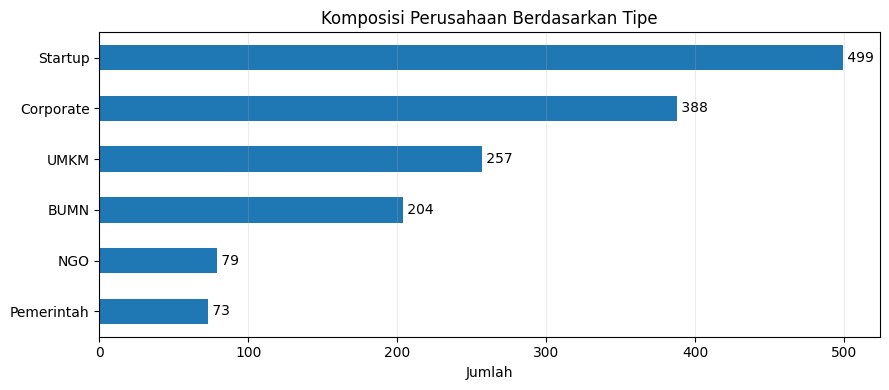

In [14]:
plot_count_bar(
    company["company_type"],
    "Komposisi Perusahaan Berdasarkan Tipe",
)

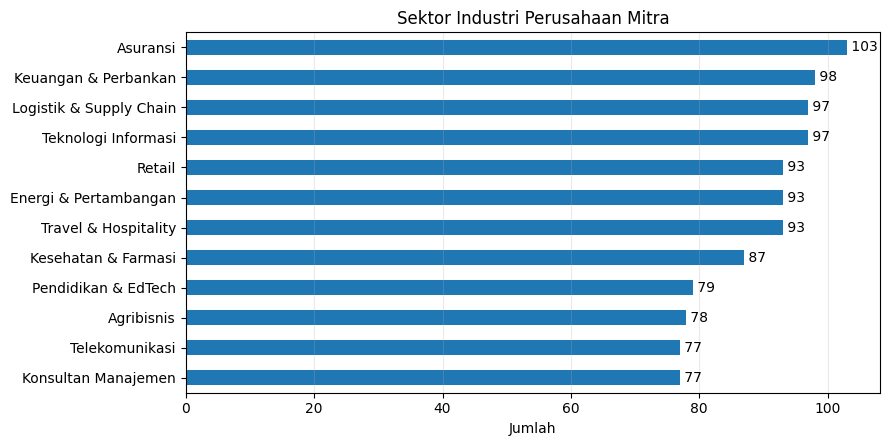

In [15]:
plot_count_bar(
    company["industry_sector"],
    "Sektor Industri Perusahaan Mitra",
    top_n=12,
)

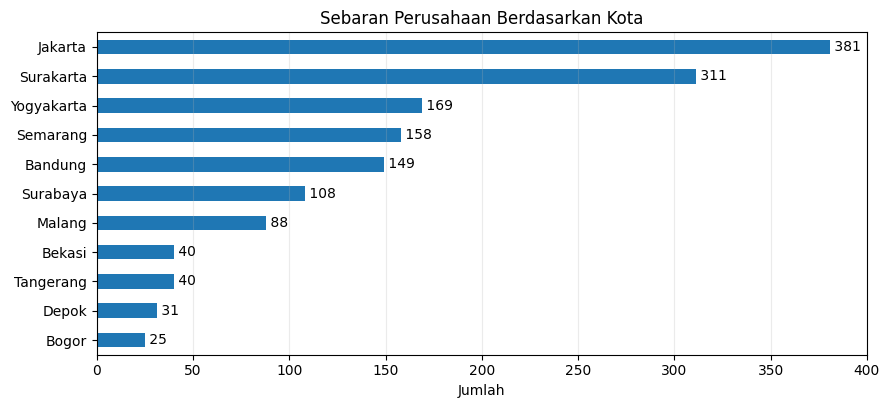

In [16]:
plot_count_bar(
    company["kota"],
    "Sebaran Perusahaan Berdasarkan Kota",
)

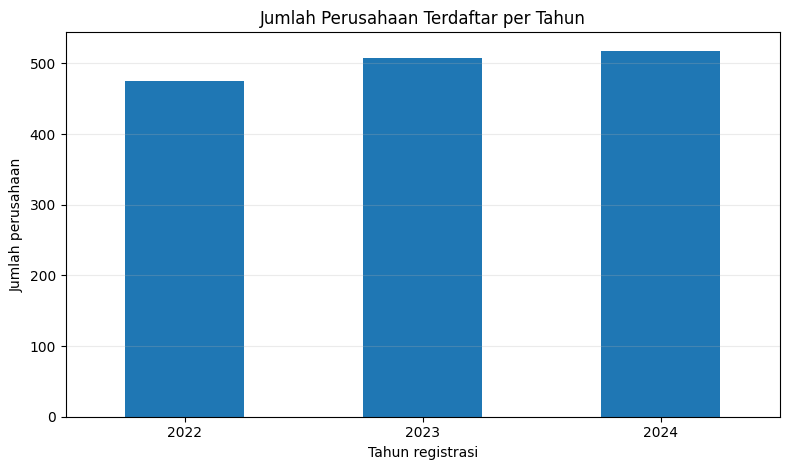

In [17]:
registration_by_year = (
    company.groupby("registration_year", dropna=False)
    .size()
)

plt.figure(figsize=(8, 4.8))
registration_by_year.plot(kind="bar")
plt.title("Jumlah Perusahaan Terdaftar per Tahun")
plt.xlabel("Tahun registrasi")
plt.ylabel("Jumlah perusahaan")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [18]:
top_company_type = company["company_type"].value_counts().idxmax()
top_company_city = company["kota"].value_counts().idxmax()
top_company_sector = company["industry_sector"].value_counts().idxmax()

display(
    Markdown(
        f"""
**Interpretasi awal tabel `company`:**

- Dataset memuat **{company['id_company'].nunique():,} perusahaan**.
- Tipe perusahaan yang paling banyak adalah **{top_company_type}**.
- Kota dengan perusahaan mitra terbanyak adalah **{top_company_city}**.
- Sektor dengan jumlah perusahaan terbesar adalah **{top_company_sector}**.
- Temuan ini baru menggambarkan komposisi mitra, belum menunjukkan kualitas atau keberhasilan placement.
"""
    )
)


**Interpretasi awal tabel `company`:**

- Dataset memuat **1,500 perusahaan**.
- Tipe perusahaan yang paling banyak adalah **Startup**.
- Kota dengan perusahaan mitra terbanyak adalah **Jakarta**.
- Sektor dengan jumlah perusahaan terbesar adalah **Asuransi**.
- Temuan ini baru menggambarkan komposisi mitra, belum menunjukkan kualitas atau keberhasilan placement.


## 9. Eksplorasi tabel `talent_request`

**Grain:** satu baris mewakili satu permintaan posisi dari perusahaan.

Fokus eksplorasi:

- volume request dan total headcount;
- jenis penempatan;
- working arrangement;
- posisi dan program studi yang dicari;
- durasi serta remunerasi;
- tren waktu permintaan.

In [19]:
talent_request_summary = pd.Series(
    {
        "jumlah_talent_request": talent_request["id_talent_req"].nunique(),
        "total_headcount": talent_request["headcount"].sum(),
        "rata_rata_headcount": talent_request["headcount"].mean(),
        "jumlah_posisi_unik": talent_request["nama_posisi"].nunique(),
        "tanggal_request_pertama": talent_request["request_date"].min(),
        "tanggal_request_terakhir": talent_request["request_date"].max(),
    },
    name="ringkasan_talent_request",
)

display(talent_request_summary.to_frame())

,ringkasan_talent_request
jumlah_talent_request,12000
total_headcount,28717
rata_rata_headcount,2.39
jumlah_posisi_unik,74
tanggal_request_pertama,2023-02-01 00:00:00
tanggal_request_terakhir,2025-01-31 00:00:00


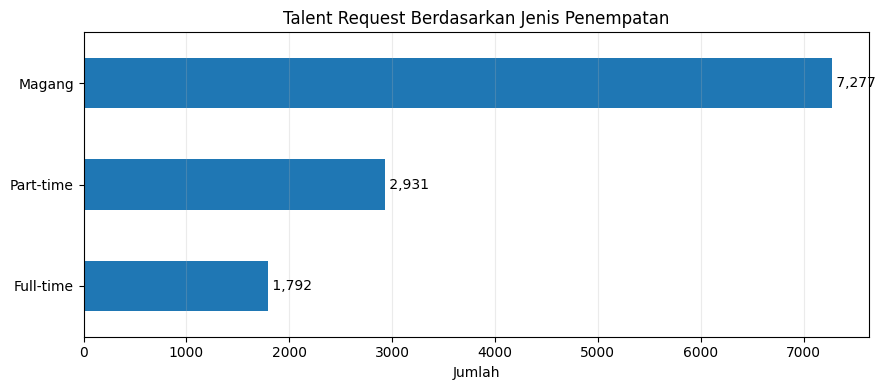

In [20]:
plot_count_bar(
    talent_request["jenis_penempatan"],
    "Talent Request Berdasarkan Jenis Penempatan",
)

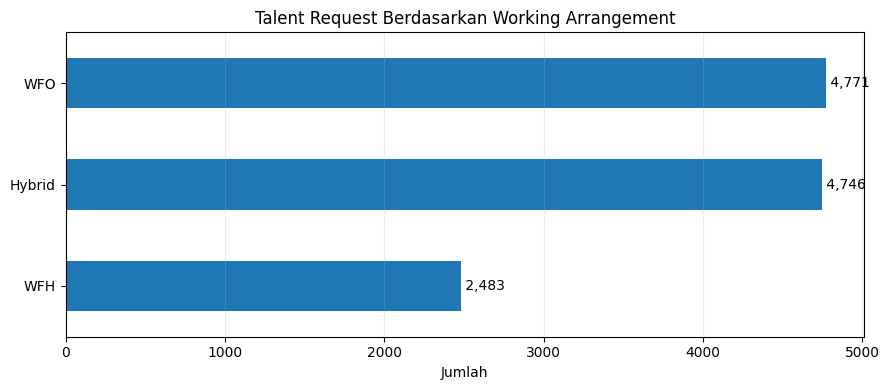

In [21]:
plot_count_bar(
    talent_request["working_arrangement"],
    "Talent Request Berdasarkan Working Arrangement",
)

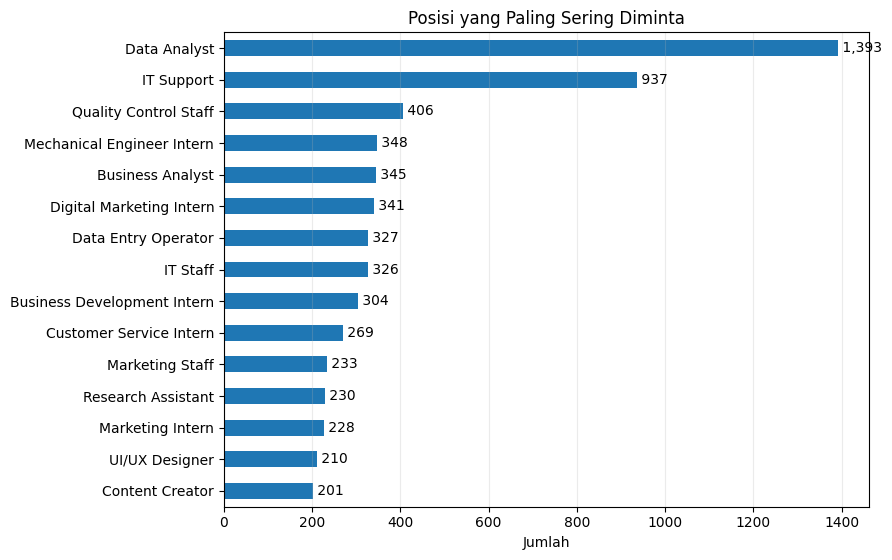

In [22]:
plot_count_bar(
    talent_request["nama_posisi"],
    "Posisi yang Paling Sering Diminta",
    top_n=15,
)

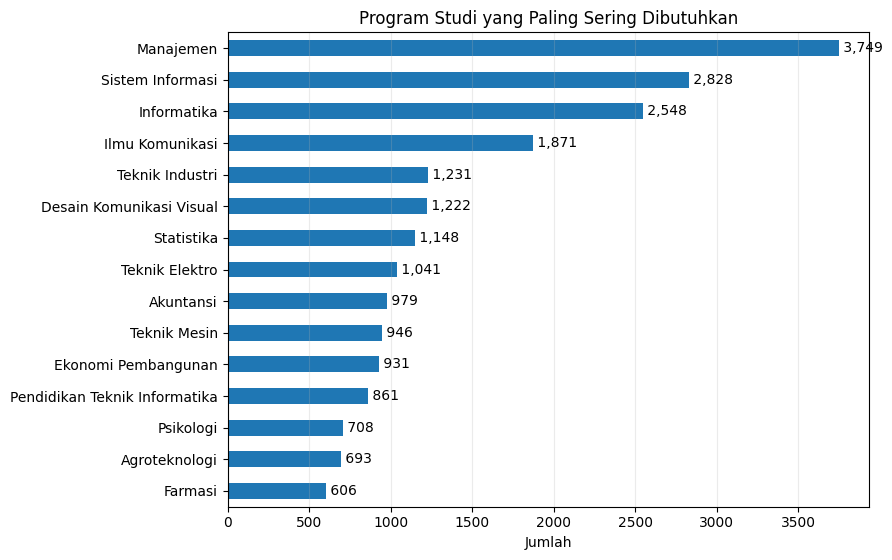

In [23]:
required_study = split_multivalue(
    talent_request["bidang_studi_dibutuhkan"]
)

plot_count_bar(
    required_study,
    "Program Studi yang Paling Sering Dibutuhkan",
    top_n=15,
)

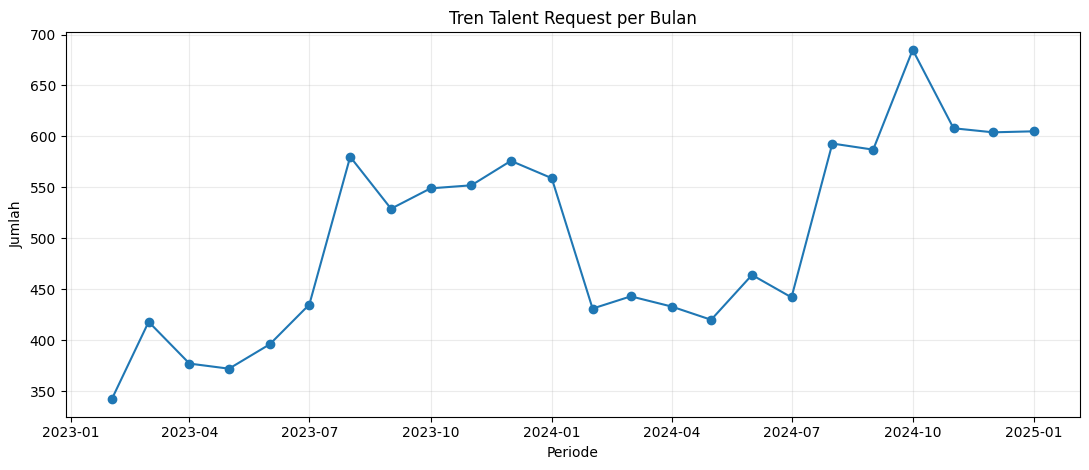

In [24]:
request_by_month = (
    talent_request.groupby("request_month")
    .size()
)

plot_time_series(
    request_by_month,
    "Tren Talent Request per Bulan",
)

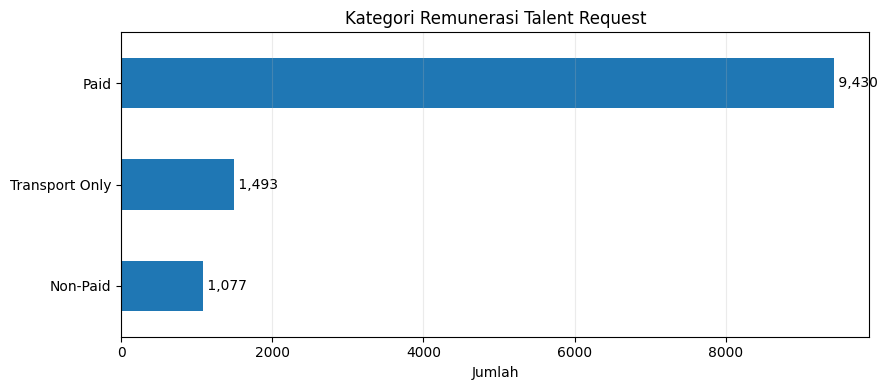

In [25]:
plot_count_bar(
    talent_request["remuneration_type"],
    "Kategori Remunerasi Talent Request",
)

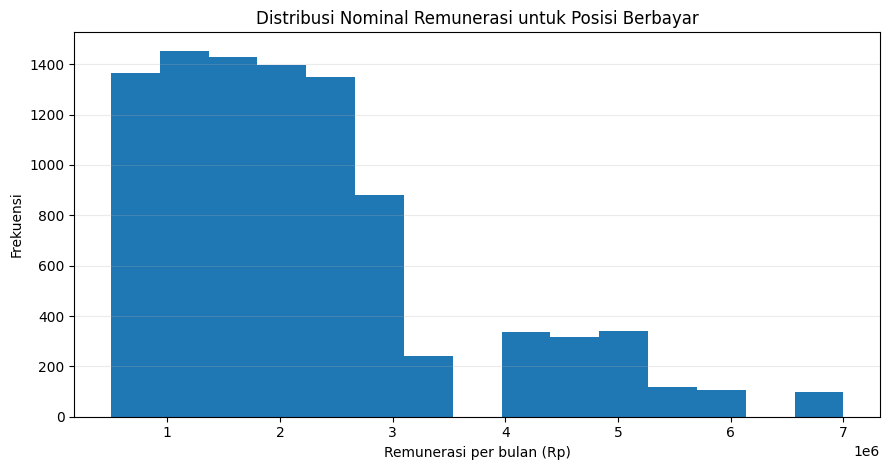

In [26]:
paid_request = talent_request.loc[
    talent_request["remuneration_type"].eq("Paid"),
    "remuneration_amount",
]

plot_histogram(
    paid_request,
    "Distribusi Nominal Remunerasi untuk Posisi Berbayar",
    "Remunerasi per bulan (Rp)",
    bins=15,
)

In [27]:
dominant_placement = (
    talent_request["jenis_penempatan"].value_counts().idxmax()
)
dominant_arrangement = (
    talent_request["working_arrangement"].value_counts().idxmax()
)
top_position = talent_request["nama_posisi"].value_counts().idxmax()

display(
    Markdown(
        f"""
**Interpretasi awal tabel `talent_request`:**

- Terdapat **{talent_request['id_talent_req'].nunique():,} talent request** dengan total kebutuhan **{talent_request['headcount'].sum():,} orang**.
- Jenis penempatan paling dominan adalah **{dominant_placement}**.
- Working arrangement paling banyak adalah **{dominant_arrangement}**.
- Posisi yang paling sering muncul adalah **{top_position}**.
- Kolom remunerasi telah dipisahkan menjadi posisi berbayar, non-paid, dan transport only agar mudah dianalisis pada tahap selanjutnya.
"""
    )
)


**Interpretasi awal tabel `talent_request`:**

- Terdapat **12,000 talent request** dengan total kebutuhan **28,717 orang**.
- Jenis penempatan paling dominan adalah **Magang**.
- Working arrangement paling banyak adalah **WFO**.
- Posisi yang paling sering muncul adalah **Data Analyst**.
- Kolom remunerasi telah dipisahkan menjadi posisi berbayar, non-paid, dan transport only agar mudah dianalisis pada tahap selanjutnya.


## 10. Eksplorasi tabel `student_all`

**Grain:** satu baris mewakili satu mahasiswa pada master data CDC.

Fokus eksplorasi:

- program studi;
- semester;
- bidang minat;
- preferensi jenis penempatan;
- angkatan masuk.

In [28]:
student_all_summary = pd.Series(
    {
        "jumlah_mahasiswa": student_all["nim"].nunique(),
        "jumlah_program_studi": student_all["program_studi"].nunique(),
        "semester_minimum": student_all["semester"].min(),
        "semester_maksimum": student_all["semester"].max(),
        "tahun_masuk_terawal": student_all["entry_year"].min(),
        "tahun_masuk_terbaru": student_all["entry_year"].max(),
    },
    name="ringkasan_student_all",
)

display(student_all_summary.to_frame())

,ringkasan_student_all
jumlah_mahasiswa,25000
jumlah_program_studi,18
semester_minimum,2
semester_maksimum,11
tahun_masuk_terawal,2019
tahun_masuk_terbaru,2023


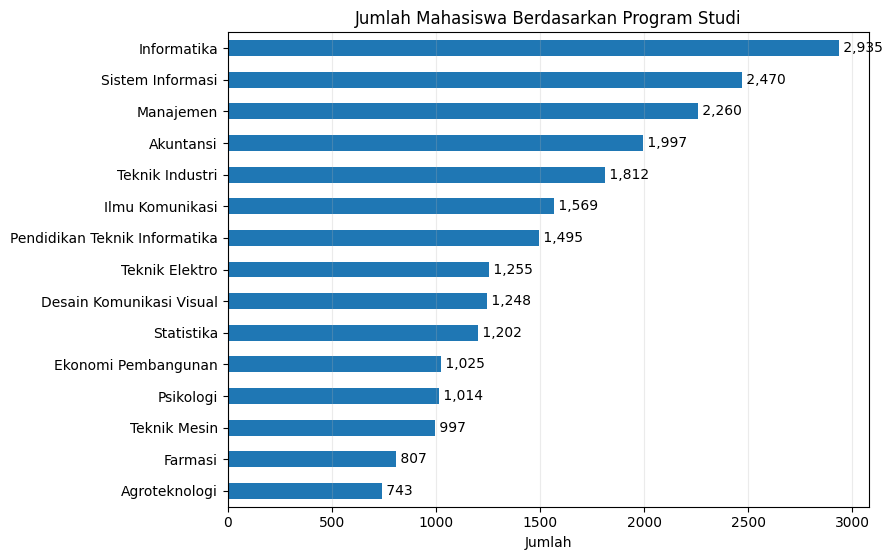

In [29]:
plot_count_bar(
    student_all["program_studi"],
    "Jumlah Mahasiswa Berdasarkan Program Studi",
    top_n=15,
)

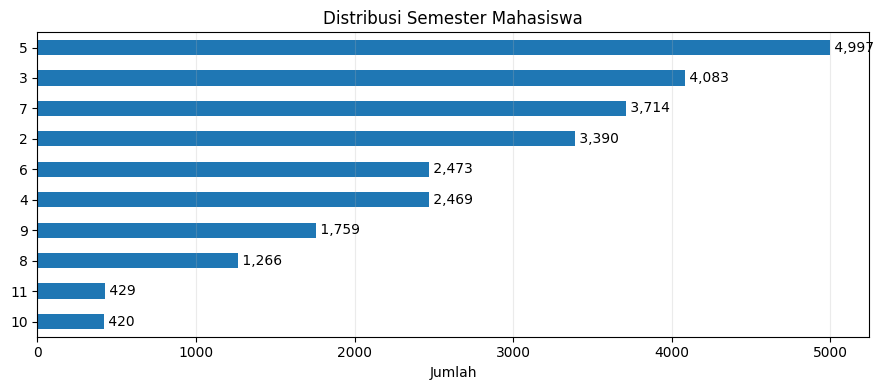

In [30]:
plot_count_bar(
    student_all["semester"].astype("string"),
    "Distribusi Semester Mahasiswa",
)

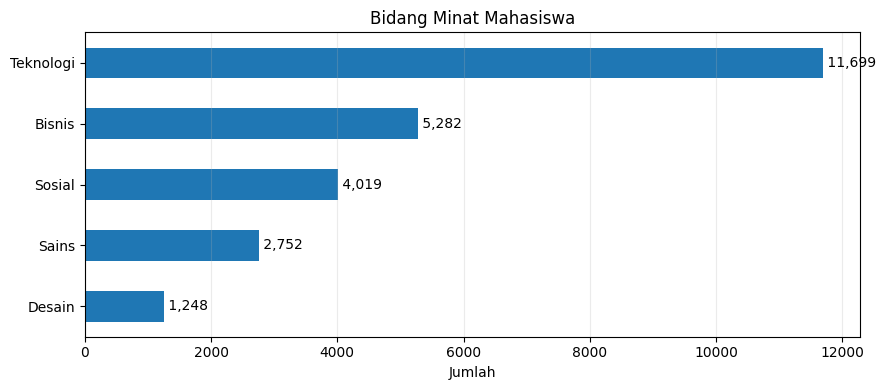

In [31]:
plot_count_bar(
    student_all["bidang_minat"],
    "Bidang Minat Mahasiswa",
)

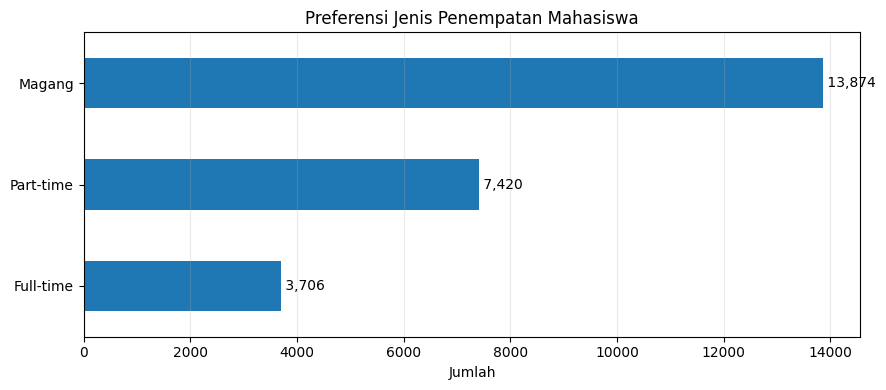

In [32]:
plot_count_bar(
    student_all["jenis_penempatan_diminati"],
    "Preferensi Jenis Penempatan Mahasiswa",
)

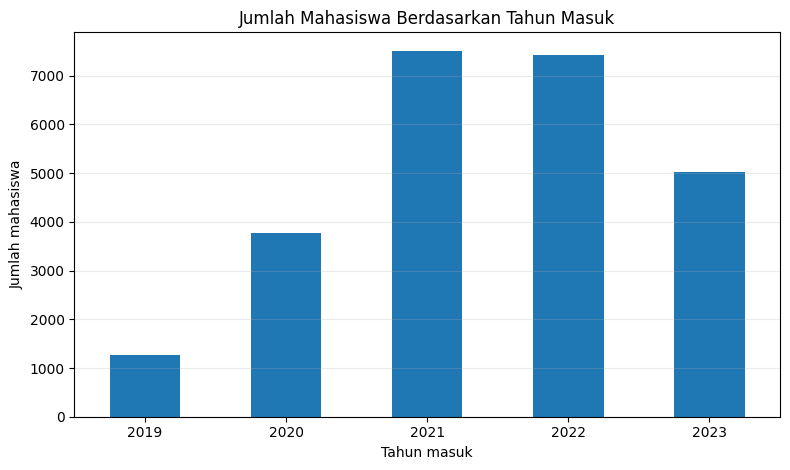

In [33]:
entry_year_counts = (
    student_all["entry_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4.8))
entry_year_counts.plot(kind="bar")
plt.title("Jumlah Mahasiswa Berdasarkan Tahun Masuk")
plt.xlabel("Tahun masuk")
plt.ylabel("Jumlah mahasiswa")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [34]:
top_study_program = student_all["program_studi"].value_counts().idxmax()
top_interest = student_all["bidang_minat"].value_counts().idxmax()
top_preference = (
    student_all["jenis_penempatan_diminati"].value_counts().idxmax()
)

display(
    Markdown(
        f"""
**Interpretasi awal tabel `student_all`:**

- Master data berisi **{student_all['nim'].nunique():,} mahasiswa** dari **{student_all['program_studi'].nunique()} program studi**.
- Program studi dengan mahasiswa terbanyak adalah **{top_study_program}**.
- Bidang minat paling dominan adalah **{top_interest}**.
- Preferensi penempatan terbanyak adalah **{top_preference}**.
- Pola ini menggambarkan sisi supply mahasiswa, tetapi belum menunjukkan mahasiswa mana yang benar-benar eligible.
"""
    )
)


**Interpretasi awal tabel `student_all`:**

- Master data berisi **25,000 mahasiswa** dari **18 program studi**.
- Program studi dengan mahasiswa terbanyak adalah **Informatika**.
- Bidang minat paling dominan adalah **Teknologi**.
- Preferensi penempatan terbanyak adalah **Magang**.
- Pola ini menggambarkan sisi supply mahasiswa, tetapi belum menunjukkan mahasiswa mana yang benar-benar eligible.


## 11. Eksplorasi tabel `status_student`

**Grain:** satu baris mewakili status terkini satu mahasiswa.

Fokus eksplorasi:

- status akademik dan ketersediaan;
- kelengkapan CV serta portofolio;
- IPK;
- tools;
- kesiapan dasar;
- usia sinkronisasi data.

`basic_ready` pada notebook ini adalah indikator eksploratif, bukan keputusan final. Mahasiswa dikategorikan siap dasar apabila:

- status `Active`;
- ketersediaan `Available`;
- CV tersedia.

In [35]:
status_summary = pd.Series(
    {
        "jumlah_status_mahasiswa": status_student["nim"].nunique(),
        "mahasiswa_active": status_student["status"].eq("Active").sum(),
        "mahasiswa_available": status_student["ketersediaan"].eq("Available").sum(),
        "cv_tersedia": status_student["cv"].eq("Ada").sum(),
        "portofolio_tersedia": status_student["portofolio"].eq("Ada").sum(),
        "basic_ready": status_student["basic_ready"].sum(),
        "rata_rata_ipk": status_student["ipk"].mean(),
        "tanggal_sinkronisasi_terakhir": status_reference_date,
    },
    name="ringkasan_status_student",
)

display(status_summary.to_frame())

,ringkasan_status_student
jumlah_status_mahasiswa,25000
mahasiswa_active,19632
mahasiswa_available,7135
cv_tersedia,21323
portofolio_tersedia,15020
basic_ready,5687
rata_rata_ipk,3.30
tanggal_sinkronisasi_terakhir,2025-01-31 00:00:00


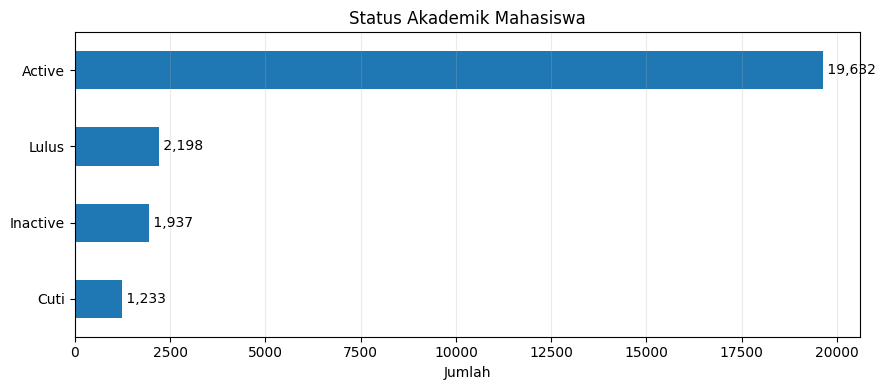

In [36]:
plot_count_bar(
    status_student["status"],
    "Status Akademik Mahasiswa",
)

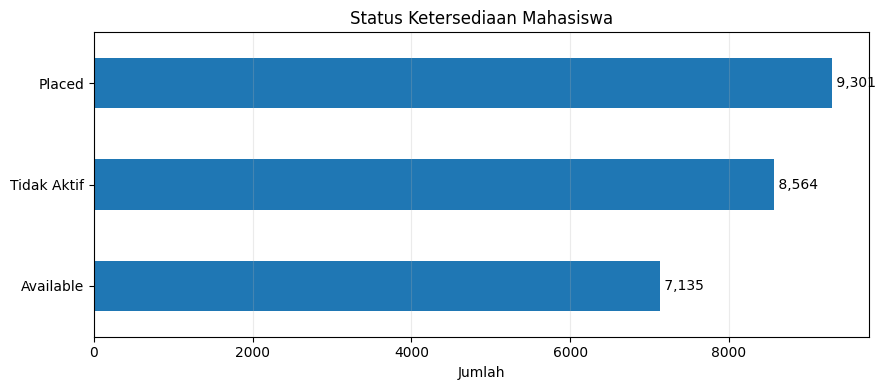

In [37]:
plot_count_bar(
    status_student["ketersediaan"],
    "Status Ketersediaan Mahasiswa",
)

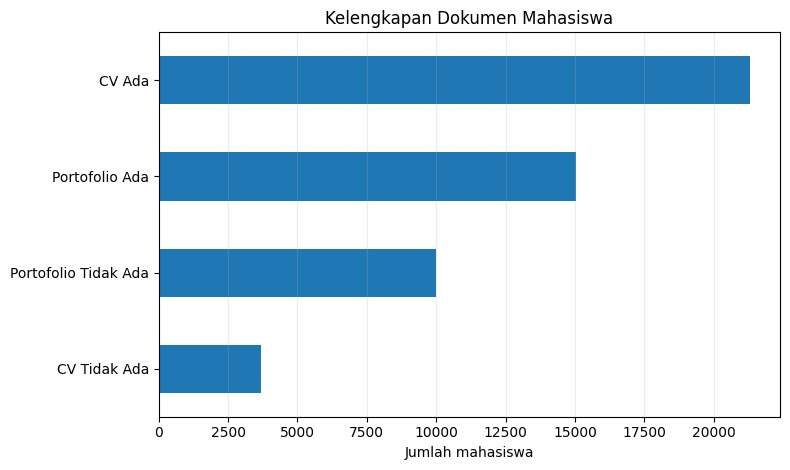

In [38]:
document_summary = pd.Series(
    {
        "CV Ada": status_student["cv"].eq("Ada").sum(),
        "CV Tidak Ada": status_student["cv"].eq("Tidak Ada").sum(),
        "Portofolio Ada": status_student["portofolio"].eq("Ada").sum(),
        "Portofolio Tidak Ada": status_student["portofolio"].eq("Tidak Ada").sum(),
    }
).sort_values()

plt.figure(figsize=(8, 4.8))
document_summary.plot(kind="barh")
plt.title("Kelengkapan Dokumen Mahasiswa")
plt.xlabel("Jumlah mahasiswa")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

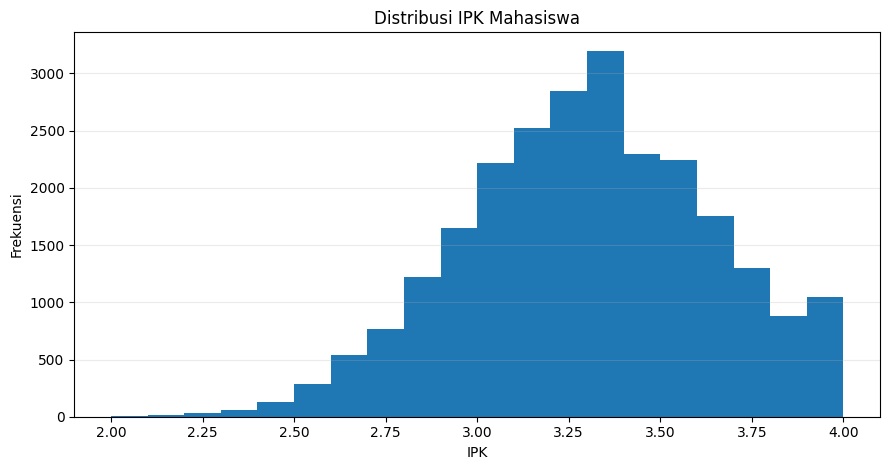

In [39]:
plot_histogram(
    status_student["ipk"],
    "Distribusi IPK Mahasiswa",
    "IPK",
    bins=20,
)

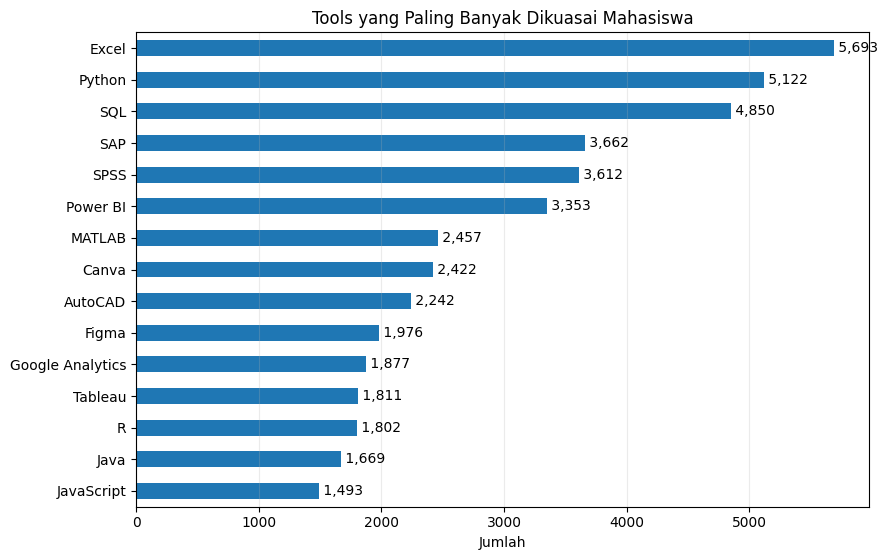

In [40]:
tools_exploded = split_multivalue(status_student["tools"])

plot_count_bar(
    tools_exploded,
    "Tools yang Paling Banyak Dikuasai Mahasiswa",
    top_n=15,
)

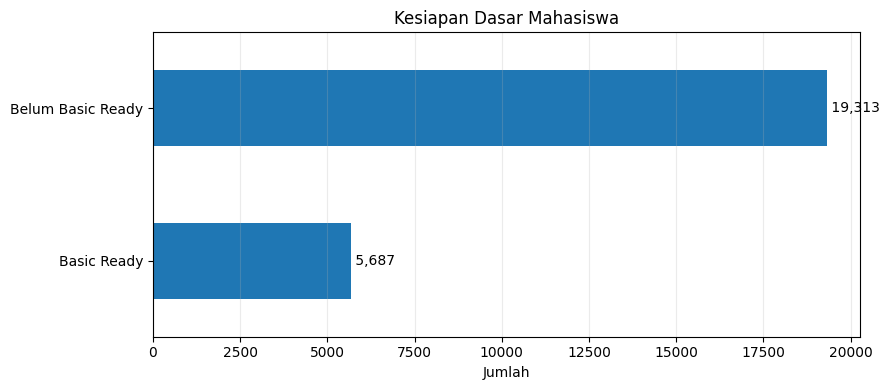

In [41]:
readiness_counts = (
    status_student["basic_ready"]
    .map({True: "Basic Ready", False: "Belum Basic Ready"})
)

plot_count_bar(
    readiness_counts,
    "Kesiapan Dasar Mahasiswa",
)

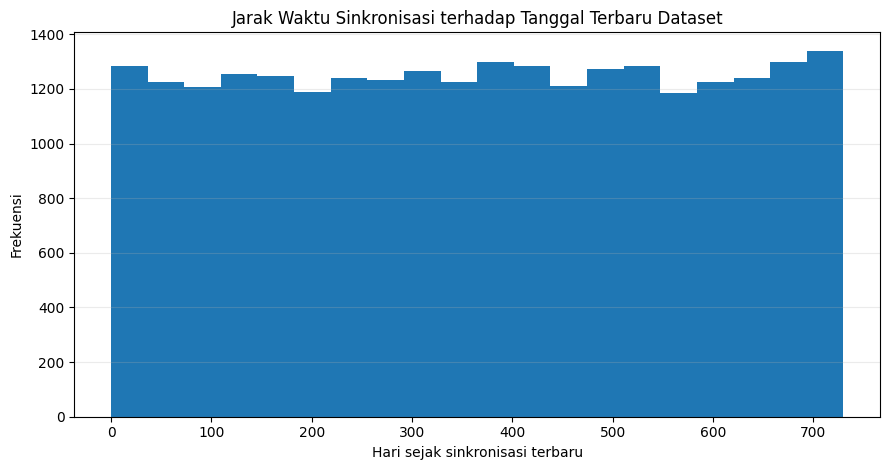

In [42]:
plot_histogram(
    status_student["days_since_sync"],
    "Jarak Waktu Sinkronisasi terhadap Tanggal Terbaru Dataset",
    "Hari sejak sinkronisasi terbaru",
    bins=20,
)

In [43]:
display(
    Markdown(
        f"""
**Interpretasi awal tabel `status_student`:**

- **{status_student['status'].eq('Active').sum():,} mahasiswa** berstatus aktif.
- **{status_student['ketersediaan'].eq('Available').sum():,} mahasiswa** tercatat available.
- Berdasarkan aturan eksploratif, **{status_student['basic_ready'].sum():,} mahasiswa** memenuhi kesiapan dasar.
- Rata-rata IPK adalah **{status_student['ipk'].mean():.2f}**.
- Indikator kesiapan final tetap harus disesuaikan dengan syarat setiap talent request, seperti semester, program studi, tools, jenis penempatan, dan lokasi.
"""
    )
)


**Interpretasi awal tabel `status_student`:**

- **19,632 mahasiswa** berstatus aktif.
- **7,135 mahasiswa** tercatat available.
- Berdasarkan aturan eksploratif, **5,687 mahasiswa** memenuhi kesiapan dasar.
- Rata-rata IPK adalah **3.30**.
- Indikator kesiapan final tetap harus disesuaikan dengan syarat setiap talent request, seperti semester, program studi, tools, jenis penempatan, dan lokasi.


## 12. Eksplorasi tabel `tracking_company`

**Grain:** satu baris mewakili satu proses atau batch pengiriman kandidat untuk satu talent request.

Fokus eksplorasi:

- progress;
- jumlah permintaan dan kandidat yang dikirim;
- waktu dari request sampai pengiriman;
- coverage ratio;
- missing value yang terkait status draft.

In [44]:
tracking_company_summary = pd.Series(
    {
        "jumlah_tracking_company": tracking_company["id_tracking_company"].nunique(),
        "total_jumlah_permintaan": tracking_company["jumlah_permintaan"].sum(),
        "total_jumlah_dikirimkan": tracking_company["jumlah_dikirimkan"].sum(),
        "median_hari_ke_pengiriman": tracking_company["days_to_send"].median(),
        "request_belum_dikirim": tracking_company["send_date"].isna().sum(),
        "rata_rata_coverage_ratio": tracking_company["coverage_ratio"].mean(),
    },
    name="ringkasan_tracking_company",
)

display(tracking_company_summary.to_frame())

,ringkasan_tracking_company
jumlah_tracking_company,"12,000.00"
total_jumlah_permintaan,"28,717.00"
total_jumlah_dikirimkan,"41,600.00"
median_hari_ke_pengiriman,12.00
request_belum_dikirim,598.00
rata_rata_coverage_ratio,1.61


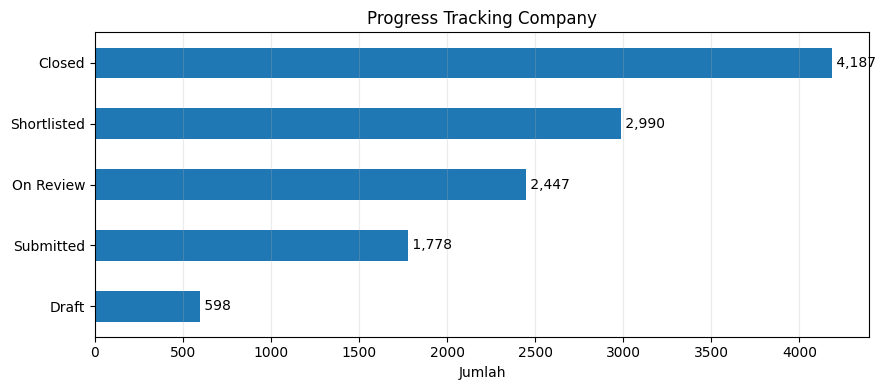

In [45]:
plot_count_bar(
    tracking_company["progress"],
    "Progress Tracking Company",
)

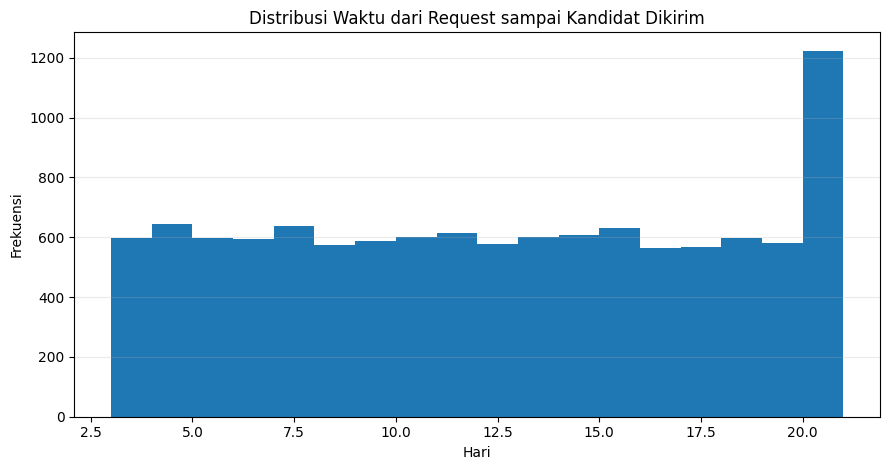

In [46]:
plot_histogram(
    tracking_company["days_to_send"],
    "Distribusi Waktu dari Request sampai Kandidat Dikirim",
    "Hari",
    bins=18,
)

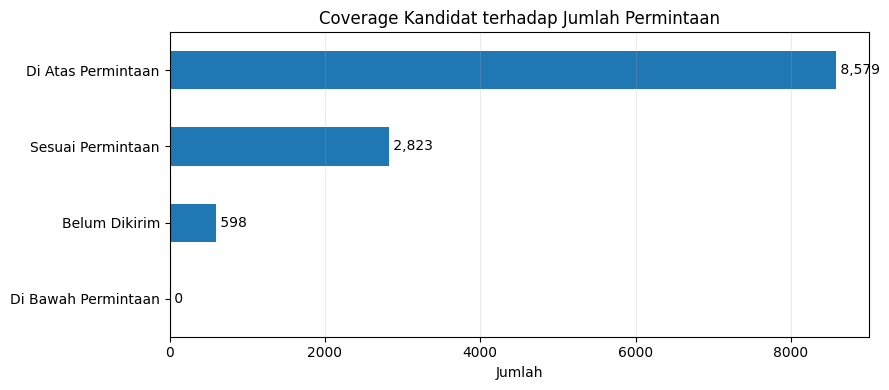

In [47]:
coverage_category = pd.cut(
    tracking_company["coverage_ratio"],
    bins=[-np.inf, 0, 0.99, 1, np.inf],
    labels=[
        "Belum Dikirim",
        "Di Bawah Permintaan",
        "Sesuai Permintaan",
        "Di Atas Permintaan",
    ],
)

plot_count_bar(
    coverage_category,
    "Coverage Kandidat terhadap Jumlah Permintaan",
)

In [48]:
missing_by_progress = (
    tracking_company.assign(
        send_date_missing=tracking_company["send_date"].isna(),
        list_nim_missing=tracking_company["list_nim"].isna(),
    )
    .groupby("progress")[
        ["send_date_missing", "list_nim_missing"]
    ]
    .sum()
)

display(missing_by_progress)

,send_date_missing,list_nim_missing
progress,,
Closed,0,0
Draft,598,598
On Review,0,0
Shortlisted,0,0
Submitted,0,0


In [49]:
list_count_mismatch = (
    tracking_company["list_nim_count"]
    != tracking_company["jumlah_dikirimkan"]
).sum()

student_count_per_tracking = (
    tracking_student.groupby("id_tracking_company")
    .size()
    .rename("jumlah_baris_tracking_student")
)

tracking_count_validation = tracking_company.merge(
    student_count_per_tracking,
    on="id_tracking_company",
    how="left",
)

tracking_count_validation["jumlah_baris_tracking_student"] = (
    tracking_count_validation["jumlah_baris_tracking_student"]
    .fillna(0)
    .astype("Int64")
)

tracking_row_mismatch = (
    tracking_count_validation["jumlah_baris_tracking_student"]
    != tracking_count_validation["jumlah_dikirimkan"]
).sum()

validation_tracking = pd.Series(
    {
        "list_nim_tidak_sesuai_jumlah_dikirimkan": int(list_count_mismatch),
        "jumlah_tracking_student_tidak_sesuai_jumlah_dikirimkan": int(
            tracking_row_mismatch
        ),
    },
    name="validasi_tracking",
)

display(validation_tracking.to_frame())

,validasi_tracking
list_nim_tidak_sesuai_jumlah_dikirimkan,0
jumlah_tracking_student_tidak_sesuai_jumlah_dikirimkan,0


In [50]:
display(
    Markdown(
        f"""
**Interpretasi awal tabel `tracking_company`:**

- Terdapat **{tracking_company['id_tracking_company'].nunique():,} record tracking perusahaan**.
- Total kandidat yang dikirim adalah **{tracking_company['jumlah_dikirimkan'].sum():,}**, sedangkan total jumlah permintaan adalah **{tracking_company['jumlah_permintaan'].sum():,}**.
- Median waktu pengiriman kandidat adalah **{tracking_company['days_to_send'].median():.0f} hari** sejak request diterima.
- Sebanyak **{tracking_company['send_date'].isna().sum():,} record** belum memiliki `send_date`. Pemeriksaan status menunjukkan kekosongan tersebut berhubungan dengan record `Draft`.
- Jumlah NIM pada `list_nim` konsisten dengan `jumlah_dikirimkan`, sehingga kolom tersebut dapat digunakan sebagai validasi tambahan.
"""
    )
)


**Interpretasi awal tabel `tracking_company`:**

- Terdapat **12,000 record tracking perusahaan**.
- Total kandidat yang dikirim adalah **41,600**, sedangkan total jumlah permintaan adalah **28,717**.
- Median waktu pengiriman kandidat adalah **12 hari** sejak request diterima.
- Sebanyak **598 record** belum memiliki `send_date`. Pemeriksaan status menunjukkan kekosongan tersebut berhubungan dengan record `Draft`.
- Jumlah NIM pada `list_nim` konsisten dengan `jumlah_dikirimkan`, sehingga kolom tersebut dapat digunakan sebagai validasi tambahan.


## 13. Eksplorasi tabel `tracking_student`

**Grain:** satu baris mewakili satu mahasiswa dalam satu proses seleksi perusahaan.

Fokus eksplorasi:

- tahapan seleksi;
- outcome;
- alasan rejection;
- proses yang sudah lama tidak diperbarui;
- konsistensi antara `progress_student` dan `rejection`.

Kolom `outcome_group` dibuat untuk membantu pembacaan awal:

- `Placement`;
- `Rejected`;
- `Ghosting`;
- `On Progress`;
- `Finish - Unclear`.

Kategori `Finish - Unclear` menunjukkan record `Finish` tetapi kolom outcome masih `On Progress`, sehingga perlu dikaji sebelum membuat KPI final.

In [51]:
tracking_student_summary = pd.Series(
    {
        "jumlah_proses_kandidat": tracking_student["id_tracking_student"].nunique(),
        "jumlah_mahasiswa_unik": tracking_student["nim"].nunique(),
        "jumlah_perusahaan_unik": tracking_student["company"].nunique(),
        "placement": tracking_student["outcome_group"].eq("Placement").sum(),
        "rejected": tracking_student["outcome_group"].eq("Rejected").sum(),
        "ghosting": tracking_student["outcome_group"].eq("Ghosting").sum(),
        "finish_unclear": tracking_student["outcome_group"].eq(
            "Finish - Unclear"
        ).sum(),
        "tanggal_update_terakhir": tracking_reference_date,
    },
    name="ringkasan_tracking_student",
)

display(tracking_student_summary.to_frame())

,ringkasan_tracking_student
jumlah_proses_kandidat,41600
jumlah_mahasiswa_unik,10174
jumlah_perusahaan_unik,1488
placement,8955
rejected,11736
ghosting,3421
finish_unclear,2578
tanggal_update_terakhir,2025-05-17 00:00:00


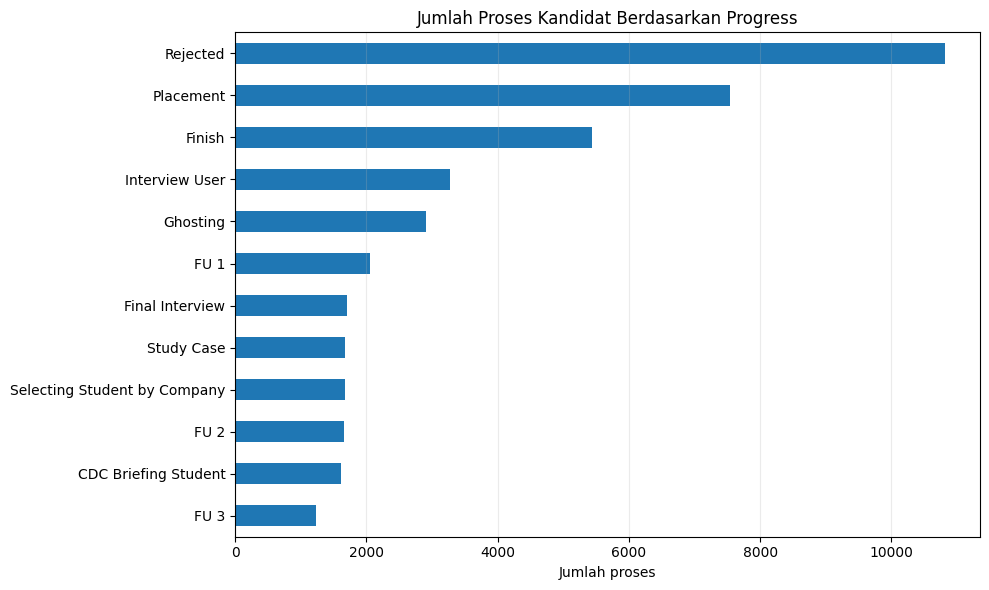

In [52]:
progress_order = [
    "Selecting Student by Company",
    "Study Case",
    "CDC Briefing Student",
    "Interview User",
    "Final Interview",
    "Placement",
    "FU 1",
    "FU 2",
    "FU 3",
    "Ghosting",
    "Rejected",
    "Finish",
]

progress_counts = (
    tracking_student["progress_student"]
    .value_counts()
    .reindex(progress_order)
    .dropna()
    .sort_values()
)

plt.figure(figsize=(10, 6))
progress_counts.plot(kind="barh")
plt.title("Jumlah Proses Kandidat Berdasarkan Progress")
plt.xlabel("Jumlah proses")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

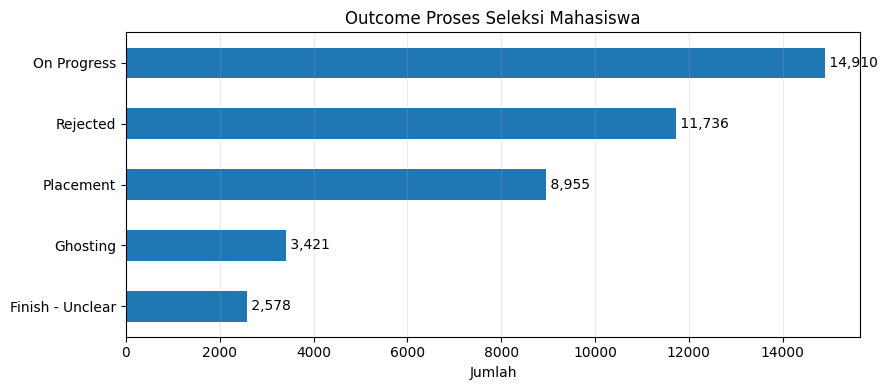

In [53]:
plot_count_bar(
    tracking_student["outcome_group"],
    "Outcome Proses Seleksi Mahasiswa",
)

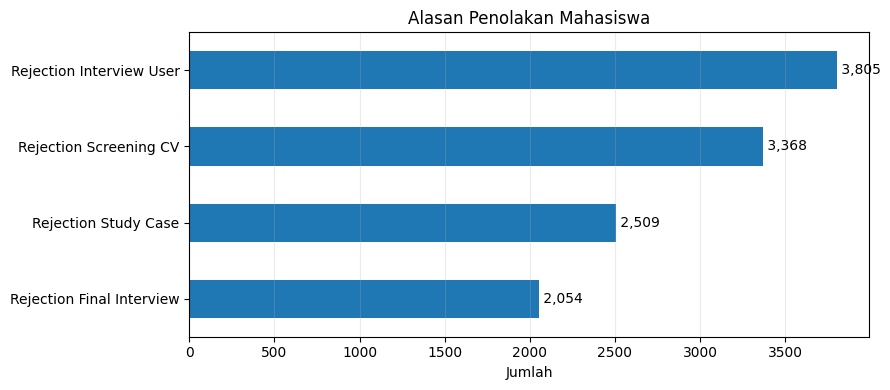

In [54]:
rejection_reason = tracking_student.loc[
    tracking_student["rejection"].str.startswith(
        "Rejection",
        na=False,
    ),
    "rejection",
]

plot_count_bar(
    rejection_reason,
    "Alasan Penolakan Mahasiswa",
)

In [55]:
status_crosscheck = pd.crosstab(
    tracking_student["progress_student"],
    tracking_student["rejection"],
)

display(status_crosscheck)

rejection,Ghosting,On Progress,Placement,Rejection Final Interview,Rejection Interview User,Rejection Screening CV,Rejection Study Case
progress_student,,,,,,,
CDC Briefing Student,0,1619,0,0,0,0,0
FU 1,0,2062,0,0,0,0,0
FU 2,0,1657,0,0,0,0,0
FU 3,0,1236,0,0,0,0,0
Final Interview,0,1707,0,0,0,0,0
Finish,516,2578,1421,0,474,453,0
Ghosting,2905,0,0,0,0,0,0
Interview User,0,3278,0,0,0,0,0
Placement,0,0,7534,0,0,0,0


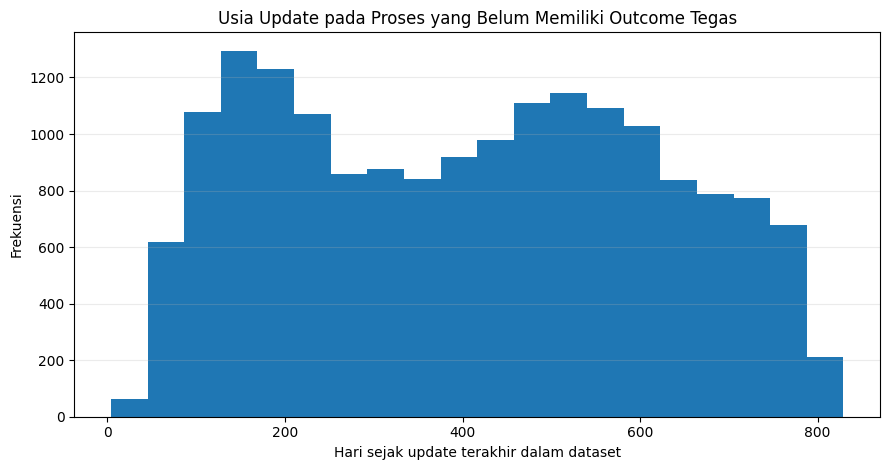

In [56]:
active_process = tracking_student[
    tracking_student["outcome_group"].isin(
        ["On Progress", "Finish - Unclear"]
    )
]

plot_histogram(
    active_process["days_since_update"],
    "Usia Update pada Proses yang Belum Memiliki Outcome Tegas",
    "Hari sejak update terakhir dalam dataset",
    bins=20,
)

In [57]:
display(
    Markdown(
        f"""
**Interpretasi awal tabel `tracking_student`:**

- Terdapat **{tracking_student['id_tracking_student'].nunique():,} proses kandidat** yang melibatkan **{tracking_student['nim'].nunique():,} mahasiswa unik**.
- Outcome awal mencatat **{tracking_student['outcome_group'].eq('Placement').sum():,} placement**, **{tracking_student['outcome_group'].eq('Rejected').sum():,} rejection**, dan **{tracking_student['outcome_group'].eq('Ghosting').sum():,} ghosting**.
- Terdapat **{tracking_student['outcome_group'].eq('Finish - Unclear').sum():,} record `Finish`** yang masih memiliki outcome `On Progress`. Record ini perlu diputuskan perlakuannya sebelum acceptance rate dihitung.
- `progress_student` sebaiknya digunakan untuk membaca tahap proses, sedangkan `rejection` atau `outcome_group` digunakan untuk membaca hasil akhir.
"""
    )
)


**Interpretasi awal tabel `tracking_student`:**

- Terdapat **41,600 proses kandidat** yang melibatkan **10,174 mahasiswa unik**.
- Outcome awal mencatat **8,955 placement**, **11,736 rejection**, dan **3,421 ghosting**.
- Terdapat **2,578 record `Finish`** yang masih memiliki outcome `On Progress`. Record ini perlu diputuskan perlakuannya sebelum acceptance rate dihitung.
- `progress_student` sebaiknya digunakan untuk membaca tahap proses, sedangkan `rejection` atau `outcome_group` digunakan untuk membaca hasil akhir.


## 14. Ringkasan temuan awal seluruh tabel

Bagian ini hanya merangkum hasil pemeriksaan struktur dan pola dasar. Temuan belum menjadi kesimpulan dashboard karena belum dilakukan analisis lintas tabel dengan grain yang dirancang khusus.

In [58]:
total_missing_raw = sum(
    int(df.isna().sum().sum())
    for df in raw_tables.values()
)

all_pk_valid = (
    pk_checks["missing_key"].sum() == 0
    and pk_checks["duplicate_key"].sum() == 0
)
all_fk_valid = foreign_key_checks["record_tidak_cocok"].sum() == 0
all_denormalized_consistent = (
    denormalized_checks["jumlah_tidak_sama"].sum() == 0
)

display(
    Markdown(
        f"""
### Ringkasan

1. Dataset terdiri dari **{len(company):,} perusahaan**, **{len(talent_request):,} talent request**, **{len(student_all):,} mahasiswa**, **{len(status_student):,} status mahasiswa**, **{len(tracking_company):,} tracking perusahaan**, dan **{len(tracking_student):,} proses kandidat**.
2. Seluruh primary key dinyatakan **{'valid' if all_pk_valid else 'perlu diperiksa'}**.
3. Seluruh foreign key dinyatakan **{'valid' if all_fk_valid else 'perlu diperiksa'}**.
4. Kolom terdenormalisasi dinyatakan **{'konsisten' if all_denormalized_consistent else 'memiliki perbedaan'}** dengan tabel sumber.
5. Missing value utama berada pada `send_date` dan `list_nim` di `tracking_company`, khususnya record yang belum keluar dari status draft.
6. Dataset relatif siap untuk analisis lanjutan, tetapi definisi outcome `Finish - Unclear` perlu disepakati sebelum KPI keberhasilan dihitung.
7. Analisis berikutnya sebaiknya membentuk analytical mart terpisah untuk sisi mahasiswa, sisi talent request, dan pipeline kandidat agar tidak terjadi double counting.
"""
    )
)


### Ringkasan

1. Dataset terdiri dari **1,500 perusahaan**, **12,000 talent request**, **25,000 mahasiswa**, **25,000 status mahasiswa**, **12,000 tracking perusahaan**, dan **41,600 proses kandidat**.
2. Seluruh primary key dinyatakan **valid**.
3. Seluruh foreign key dinyatakan **valid**.
4. Kolom terdenormalisasi dinyatakan **konsisten** dengan tabel sumber.
5. Missing value utama berada pada `send_date` dan `list_nim` di `tracking_company`, khususnya record yang belum keluar dari status draft.
6. Dataset relatif siap untuk analisis lanjutan, tetapi definisi outcome `Finish - Unclear` perlu disepakati sebelum KPI keberhasilan dihitung.
7. Analisis berikutnya sebaiknya membentuk analytical mart terpisah untuk sisi mahasiswa, sisi talent request, dan pipeline kandidat agar tidak terjadi double counting.


## 15. Menyimpan data yang sudah dibersihkan

File hasil pembersihan disimpan ke folder:

`Database SSDC 2026 UNZIP/cleaned`

Kolom turunan seperti `basic_ready`, `coverage_ratio`, dan `outcome_group` ikut disimpan agar dapat diperiksa kembali. Kolom tersebut masih bersifat eksploratif dan boleh direvisi pada analisis lanjutan.

In [59]:
OUTPUT_DIR = DATA_DIR / "cleaned"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for name, df in clean_tables.items():
    output_path = OUTPUT_DIR / f"{name}_clean.csv"
    df.to_csv(output_path, index=False)

print(f"Enam file hasil pembersihan tersimpan di: {OUTPUT_DIR}")

Enam file hasil pembersihan tersimpan di: /mnt/data/Database SSDC 2026 UNZIP/cleaned


## 16. Rekomendasi tahap analisis berikutnya

Setelah notebook ini selesai diperiksa, analisis dapat dilanjutkan melalui tiga jalur:

### 1. Student readiness mart

Gabungkan `student_all` dan `status_student` dengan grain satu mahasiswa. Mart ini dapat digunakan untuk:

- kelayakan;
- kelengkapan dokumen;
- ketersediaan;
- profil tools;
- kandidat potensial.

### 2. Talent request mart

Gabungkan `company`, `talent_request`, dan `tracking_company` dengan grain yang ditetapkan secara eksplisit. Mart ini dapat digunakan untuk:

- permintaan dan headcount;
- backlog;
- kecepatan pengiriman;
- coverage kandidat;
- prioritas request.

### 3. Candidate pipeline mart

Gabungkan `tracking_student` dengan informasi tracking, request, perusahaan, dan mahasiswa. Grain-nya harus tetap:

`1 mahasiswa × 1 proses seleksi`

Mart ini dapat digunakan untuk:

- funnel seleksi;
- placement;
- rejection;
- ghosting;
- follow-up;
- performa perusahaan dan program studi.

> Jangan menggabungkan seluruh tabel lalu langsung menjumlahkan `headcount`. Relasi one-to-many dapat menggandakan angka request ketika satu request memiliki banyak kandidat.